# Query expansion and BM25 test

This notebook builds **two expansion variants** for the goldset and runs BM25 (and RM3) retrieval tests.

**Inputs**
- Gold parquet (e.g. `output/cleaned/golden_grouped.parquet`) with columns `query`, `docs`, etc.
- dictybase_files/gene_information.txt: tab-separated table with columns GENE ID, Gene Name, Synonyms (comma-separated), Gene products. Used only for query expansion; ambiguous aliases (mapping to multiple genes) are skipped.

**Expansion rules**
- Detection: A query is expanded when it contains (1) a token matching DDB_G\d+, or (2) a token matching a gene name/synonym (case-insensitive) from the table.
- Expansion: For each detected gene we append a bounded list of aliases (gene name + synonyms). We never append gene IDs (DDB_G...) even when the gene was detected via ID.
- Two variants: query_expand_synonyms (id, gene name, synonyms only) and query_expand_long (synonyms + gene products).

**Output**: Parquet with query, query_expand_synonyms, query_expand_long, query_expand (= long), docs; flat TSV for labeling.

In [1]:
import polars as pl
import pandas as pd
import pyterrier as pt
import numpy as np

import os, math
import matplotlib.pyplot as plt
import re

In [2]:
if not pt.started():
    pt.init()

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_4287/3057724015.py:1: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_4287/3057724015.py:2: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


# let us do one query test

In [22]:
INDEX_PATH = os.path.abspath("../indexes/dicty_bm25_index")
# INDEX_PATH = os.path.abspath("../indexes/_terrier_index_dicty_22.01.26")

# 1) load existing index from disk
index_ref = pt.IndexRef.of(INDEX_PATH)
index = pt.IndexFactory.of(index_ref)

# 2) BM25 retriever
br = pt.BatchRetrieve(index, wmodel="BM25")

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_4287/3826818991.py:9: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  br = pt.BatchRetrieve(index, wmodel="BM25")


In [23]:
# 3) pick one query from gold (change row index if you want)
gold = pl.read_parquet("../output/cleaned/golden_grouped.parquet")

row = gold.select(["group_claim_id", "query", "docs"]).row(100, named=True)

In [24]:
qid = str(row["group_claim_id"])
query = row["query"]
# positives = pmids from gold docs
docs = row["docs"]  # list of structs
pos_pmids = sorted({str(d.get("pmid")) for d in docs if d.get("pmid") not in (None, "", "NA")})
pos_set = set(pos_pmids)

In [25]:
print("qid:", qid)
print("query:", query)
print("n_pos_pmids:", len(pos_pmids))
print("pos_pmids (first 20):", pos_pmids[:20])

qid: 101
query: Although the IQGAP-related protein DGAP1 rgaA binds to Rac1A, it does not affect its GTPase activity.
n_pos_pmids: 2
pos_pmids (first 20): ['10825297', '9739079']


In [26]:
# 4) retrieve top K
K = 2000
qdf = pd.DataFrame([{"qid": qid, "query": query}])
res = br.transform(qdf).head(K)
res["docno"] = res["docno"].astype(str)

# 5) check where positives appear
hits = res[res["docno"].isin(pos_set)].copy().sort_values("rank")
missed = sorted(pos_set - set(res["docno"]))

print("\n--- Positive hits in top", K, "---")
print("n_hits:", len(hits), "/", len(pos_pmids))
print("best_rank:", (int(hits["rank"].min()) if len(hits) else None))
print("missed_in_topK:", len(missed))
print("missed pmids (first 20):", missed[:20])

display(hits[["qid","docno","rank","score"]].head(50))

for k in [10, 20, 50, 100, 200, 500, 1000]:
    topk = set(res[res["rank"] < k]["docno"])
    rec = len(topk & pos_set) / (len(pos_set) if len(pos_set) else 1)
    print(f"recall@{k}: {rec:.3f}")


--- Positive hits in top 2000 ---
n_hits: 2 / 2
best_rank: 1
missed_in_topK: 0
missed pmids (first 20): []


,qid,docno,rank,score
1,101,9739079,1,55.196421
3,101,10825297,3,41.753345


recall@10: 1.000
recall@20: 1.000
recall@50: 1.000
recall@100: 1.000
recall@200: 1.000
recall@500: 1.000
recall@1000: 1.000


In [27]:
# # check the abstract
# gid = gold.select("group_claim_id").row(0)[0]   # scalar int
# # or: gid = gold.get_column("group_claim_id")[0]

# pos_docs = (
#     gold
#     .filter(pl.col("group_claim_id") == gid)
#     .select(["group_claim_id", "query", "docs"])
#     .explode("docs")
#     .with_columns([
#         pl.col("docs").struct.field("pmid").alias("pmid"),
#         pl.col("docs").struct.field("publication_id").alias("publication_id"),
#         pl.col("docs").struct.field("title").alias("title"),
#         pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
#         pl.col("docs").struct.field("year").alias("year"),
#     ])
#     .drop("docs")
# )

# with pl.Config(fmt_str_lengths=10_000, tbl_rows=200, tbl_cols=20):
#     display(pos_docs)

In this first row, BM25 gives the citation at rank 0, so perfectly matched

# let us prepare the results for gold and BM25

In [28]:
# -------------------------
# build mappings for gold
# -------------------------

# qid -> query
queries_df = gold.select([
    pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
    pl.col("query").alias("query"),
])

# qid -> set(pmids)
gold_pmids = (
    gold.select(["group_claim_id", "docs"])
        .explode("docs")
        .with_columns([
            pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
            pl.col("docs").struct.field("pmid").cast(pl.Utf8).alias("pmid"),
        ])
        .filter(pl.col("pmid").is_not_null() & (pl.col("pmid") != "") & (pl.col("pmid") != "NA"))
        .select(["qid", "pmid"])
        .unique()
)

gold_map: dict[str, set[str]] = {}
for qid, pmid in gold_pmids.iter_rows():
    gold_map.setdefault(qid, set()).add(pmid)

In [29]:
# -------------------------
# Run retrieval (overfetch)
# -------------------------
qdf = queries_df.to_pandas()

K_MAX = 500
res_all = br.transform(qdf)

res = (
    res_all
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res["qid"] = res["qid"].astype(str)
res["docno"] = res["docno"].astype(str)
res = res.sort_values(["qid", "rank"], ascending=[True, True])

# Build run_map: qid -> ranked list (docno)
run_map: dict[str, list[str]] = {}
for qid, grp in res.groupby("qid", sort=False):
    run_map[qid] = grp["docno"].tolist()

In [30]:
res_all.shape, res.shape

((1702921, 6), (851901, 6))

In [31]:
len(run_map)

1705

# let us implement the eval strategy from BIOASQ

In [32]:
# -------------------------
# BioASQ-style AP + extras
# -------------------------
def ap_bioasq(ranked: list[str], relset: set[str], k: int = 10) -> float:
    """
    AP with denominator min(|relset|, k), matching BioASQ Phase A doc AP behavior.
    """
    ranked = ranked[:k]
    if not relset:
        return 0.0
    denom = min(len(relset), k)
    if denom == 0:
        return 0.0
    hits = 0
    s = 0.0
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            hits += 1
            s += hits / i
    return s / denom

def rr_at_k(ranked: list[str], relset: set[str], k: int = 10) -> float:
    ranked = ranked[:k]
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            return 1.0 / i
    return 0.0

def success_at_k(ranked: list[str], relset: set[str], k: int = 10) -> int:
    ranked = ranked[:k]
    return int(any(docno in relset for docno in ranked))

def recall_at_k(ranked: list[str], relset: set[str], k: int) -> float:
    ranked = ranked[:k]
    if not relset:
        return 0.0
    return len(set(ranked) & relset) / len(relset)

In [33]:
# -------------------------
# Evaluate baseline BM25
# -------------------------
Ks_recall = [50, 100, 200, 500]
eps_power = 5   # matches BioASQ -e 5 (epsilon = 1e-5)
eps = 10 ** (-eps_power)

def evaluate_run(gold_map: dict[str, set[str]], run_map: dict[str, list[str]], k_max: int, ks_recall: list[int] = None) -> tuple[dict, pl.DataFrame]:
    """Generic evaluation function for any run_map against gold_map"""
    if ks_recall is None:
        ks_recall = [50, 100, 200, 500]
    
    perq = []
    APs, RRs, S10s = [], [], []
    recalls = {K: [] for K in ks_recall}

    for qid, relset in gold_map.items():
        ranked = run_map.get(qid, [])

        ap = ap_bioasq(ranked, relset, k=10)
        rr = rr_at_k(ranked, relset, k=10)
        s10 = success_at_k(ranked, relset, k=10)

        APs.append(ap)
        RRs.append(rr)
        S10s.append(s10)

        rec_k_vals = {}
        for K in ks_recall:
            rK = recall_at_k(ranked, relset, k=K)
            recalls[K].append(rK)
            rec_k_vals[f"recall@{K}"] = rK

        perq.append({
            "qid": qid,
            "n_gold": len(relset),
            "AP@10": ap,
            "RR@10": rr,
            "Success@10": s10,
            **rec_k_vals,
        })

    MAP10 = sum(APs) / len(APs) if APs else 0.0
    GMAP10 = math.exp(sum(math.log(a + eps) for a in APs) / len(APs)) if APs else 0.0
    MRR10 = sum(RRs) / len(RRs) if RRs else 0.0
    Success10 = sum(S10s) / len(S10s) if S10s else 0.0
    RecallK = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls.items()}

    summary = {
        "MRR@10": MRR10,
        "Success@10": Success10,
        "MAP@10": MAP10,
        "GMAP@10": GMAP10,
        **{f"Recall@{K}": RecallK[K] for K in ks_recall},
        "n_queries": len(gold_map),
        "K_MAX_retrieved": k_max,
    }
    
    perq_df = pl.DataFrame(perq).sort("RR@10")
    return summary, perq_df

def run_retrieval(retriever, qdf: pd.DataFrame, k_max: int) -> dict[str, list[str]]:
    """Run retrieval and build run_map: qid -> ranked docno list"""
    res_all = retriever.transform(qdf)
    res = (
        res_all
        .sort_values(["qid", "rank"], ascending=[True, True])
        .groupby("qid", as_index=False)
        .head(k_max)
    )
    res["qid"] = res["qid"].astype(str)
    res["docno"] = res["docno"].astype(str)
    
    run_map = {}
    for qid, grp in res.groupby("qid", sort=False):
        run_map[qid] = grp["docno"].tolist()
    return run_map

summary, perq_df = evaluate_run(gold_map, run_map, K_MAX, Ks_recall)
print(summary)
perq_df

{'MRR@10': 0.5979265000232742, 'Success@10': 0.750733137829912, 'MAP@10': 0.5596210724759112, 'GMAP@10': 0.0398330833949438, 'Recall@50': 0.8101275427081879, 'Recall@100': 0.8507880649816134, 'Recall@200': 0.8793697342084439, 'Recall@500': 0.9118614718614718, 'n_queries': 1705, 'K_MAX_retrieved': 500}


qid,n_gold,AP@10,RR@10,Success@10,recall@50,recall@100,recall@200,recall@500
str,i64,f64,f64,i64,f64,f64,f64,f64
"""1008""",4,0.0,0.0,0,0.5,0.5,0.75,0.75
"""1385""",1,0.0,0.0,0,1.0,1.0,1.0,1.0
"""1659""",3,0.0,0.0,0,0.666667,0.666667,0.666667,1.0
"""109""",1,0.0,0.0,0,0.0,0.0,0.0,0.0
"""1391""",1,0.0,0.0,0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…
"""1224""",1,1.0,1.0,1,1.0,1.0,1.0,1.0
"""1274""",1,1.0,1.0,1,1.0,1.0,1.0,1.0
"""862""",1,1.0,1.0,1,1.0,1.0,1.0,1.0


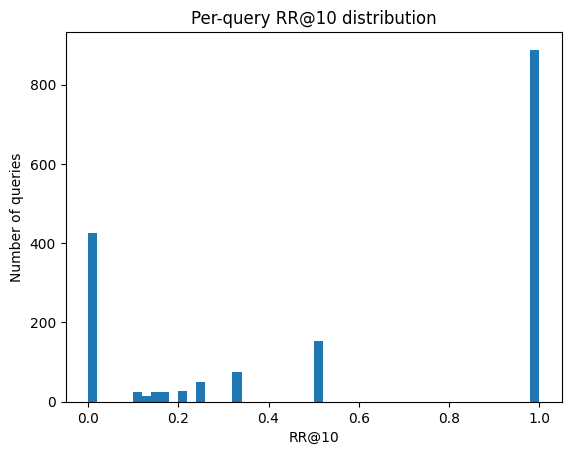

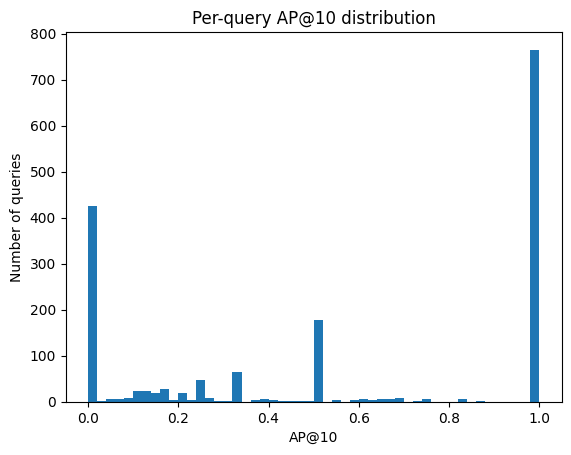

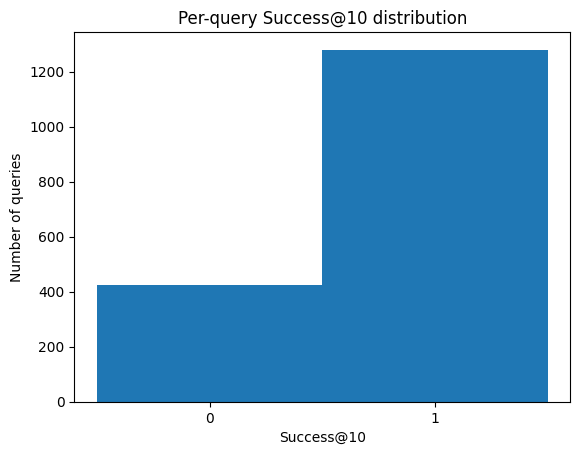

In [34]:
# perq_df: Polars DataFrame from evaluation (columns: "RR@10","AP@10","Success@10","recall@50"...)
# summary: dict from evaluation (keys: "MRR@10", "Recall@50", ...)

pdf = perq_df.to_pandas()

# 1) RR@10 distribution
plt.figure()
plt.hist(pdf["RR@10"], bins=50)
plt.title("Per-query RR@10 distribution")
plt.xlabel("RR@10")
plt.ylabel("Number of queries")
plt.show()

# 2) AP@10 distribution
plt.figure()
plt.hist(pdf["AP@10"], bins=50)
plt.title("Per-query AP@10 distribution")
plt.xlabel("AP@10")
plt.ylabel("Number of queries")
plt.show()

# 3) Success@10 distribution (0/1)
plt.figure()
plt.hist(pdf["Success@10"], bins=[-0.5, 0.5, 1.5])
plt.title("Per-query Success@10 distribution")
plt.xlabel("Success@10")
plt.ylabel("Number of queries")
plt.xticks([0, 1])
plt.show()

this can be seen as a baseline result. looks OK

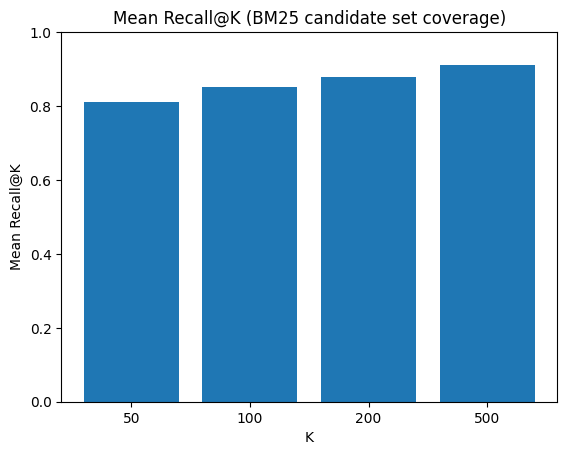

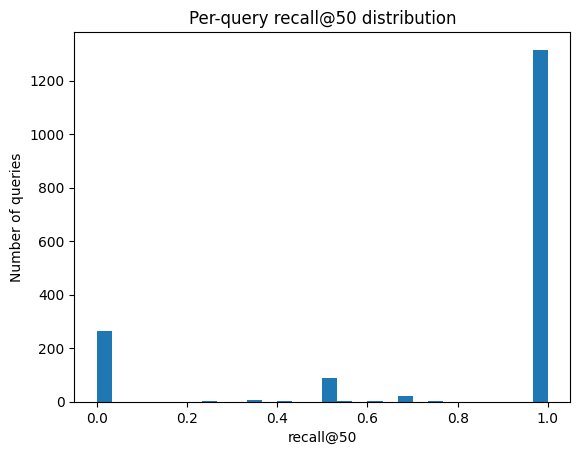

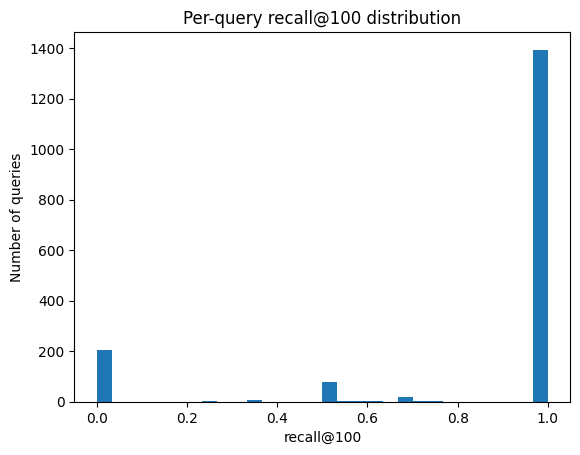

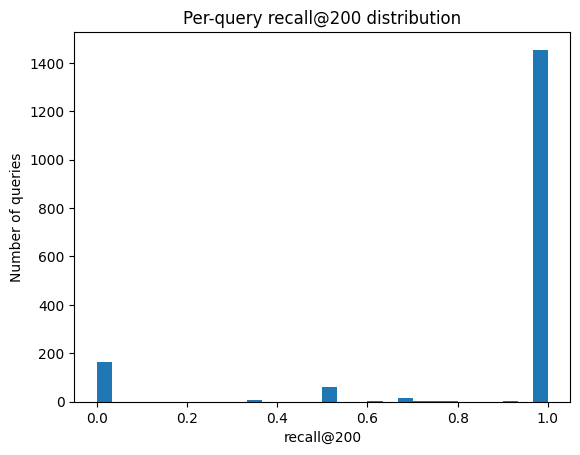

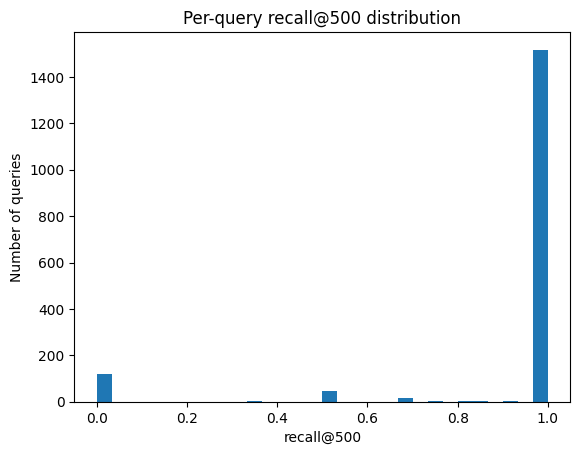

In [35]:
# 4) Mean Recall@K bar chart
Ks = [50, 100, 200, 500]
rec_vals = [summary.get(f"Recall@{k}", 0.0) for k in Ks]

plt.figure()
plt.bar([str(k) for k in Ks], rec_vals)
plt.title("Mean Recall@K (BM25 candidate set coverage)")
plt.xlabel("K")
plt.ylabel("Mean Recall@K")
plt.ylim(0, 1)
plt.show()

# 5) Optional: per-query Recall@K distributions
for k in Ks:
    col = f"recall@{k}"
    if col in pdf.columns:
        plt.figure()
        plt.hist(pdf[col], bins=30)
        plt.title(f"Per-query {col} distribution")
        plt.xlabel(col)
        plt.ylabel("Number of queries")
        plt.ylim(bottom=0)
        plt.show()

In [36]:
# qids where BM25 retrieved none of the gold docs in top 500
zero_qids = (
    perq_df
    .filter(pl.col("recall@500") == 0)
    .select(pl.col("qid").cast(pl.Utf8))
)

# Pull query + gold docs for those qids
zero_cases = (
    gold
    .with_columns(pl.col("group_claim_id").cast(pl.Utf8).alias("qid"))
    .join(zero_qids, on="qid", how="inner")
    .select(["qid", "query", "docs", "n_citations", "n_variants"])
    .explode("docs")
    .with_columns([
        pl.col("docs").struct.field("pmid").alias("pmid"),
        pl.col("docs").struct.field("publication_id").alias("publication_id"),
        pl.col("docs").struct.field("title").alias("title"),
        pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
        pl.col("docs").struct.field("year").alias("year"),
    ])
    .drop("docs")
    .sort(["qid", "pmid"])
)

# with pl.Config(fmt_str_lengths=10_000, tbl_rows=5000, tbl_cols=30):
#     display(zero_cases)
zero_cases

qid,query,n_citations,n_variants,pmid,publication_id,title,abstract_clean,year
str,str,u32,u32,str,i64,str,str,i32
"""1002""","""pirA /AX2 null cells also have…",1,1,"""28889942""",16764,"""Differential functions of WAVE…","""The WAVE regulatory complex (W…",2017
"""1005""","""PKA is also part of the signal…",1,1,"""9584128""",3792,"""YakA, a protein kinase require…","""When Dictyostelium cells starv…",1998
"""1057""","""rab7A is expressed at a relati…",1,2,"""9243512""",4031,"""Evidence for a recycling role …","""The mammalian small molecular …",1997
"""1059""","""rab32A is expressed at very lo…",1,1,"""10025509""",3202,"""Molecular characterization of …","""The superfamily of small GTPas…",1999
"""109""","""An analysis of Dictyostelium r…",1,6,"""29614268""",17329,"""Loss of RapC causes defects in…","""The small GTPase Ras proteins …",2018
…,…,…,…,…,…,…,…,…
"""961""","""Over-expression of pdeE leads …",1,1,"""12429832""",2105,"""Identification and characteriz…","""Recently, we recognized two ge…",2002
"""979""","""pdeE is expressed between 6 an…",1,1,"""25887420""",14621,"""Leaps and lulls in the develop…","""Background Development of the …",2015
"""982""","""PefBhas been shown to localize…",2,2,"""11481037""",2415,"""Identification and characteriz…","""Penta-EF-hand (PEF) proteins s…",2001


In [37]:
with pl.Config(fmt_str_lengths=10_000, tbl_rows=5, tbl_cols=30):
    display(zero_cases)

qid,query,n_citations,n_variants,pmid,publication_id,title,abstract_clean,year
str,str,u32,u32,str,i64,str,str,i32
"""1002""","""pirA /AX2 null cells also have defects in cytokinesis and cell motility.""",1,1,"""28889942""",16764,"""Differential functions of WAVE regulatory complex subunits in the regulation of actin-driven processes.""","""The WAVE regulatory complex (WRC) links upstream Rho-family GTPase signaling to the activation of the ARP2/3 complex in different organisms. WRC-induced and ARP2/3 complex-mediated actin nucleation beneath the plasma membrane is critical for actin assembly in the leading edge to drive efficient cell migration. The WRC is a stable heteropentamer composed of SCAR/WAVE, Abi, Nap, Pir and the small polypeptide Brk1/Hspc300. Functional interference with individual subunits of the complex frequently results in diminished amounts of the remaining polypeptides of the WRC complex, implying the complex to act as molecular entity. However, Abi was also found to associate with mammalian N-WASP, formins, Eps8/SOS1 or VASP, indicating additional functions of individual WRC subunits in eukaryotic cells. To address this issue systematically, we inactivated all WRC subunits, either alone or in combination with VASP in Dictyostelium cells and quantified the protein content of the remaining subunits in respective WRC knockouts. The individual mutants displayed highly differential phenotypes concerning various parameters, including cell morphology, motility, cytokinesis or multicellular development, corroborating the view of additional roles for individual subunits, beyond their established function in WRC-mediated Arp2/3 complex activation. Finally, our data uncover the interaction of the actin polymerase VASP with WRC-embedded Abi to mediate VASP accumulation in cell protrusions, driving efficient cell migration.""",2017
"""1005""","""PKA is also part of the signal transduction pathway by which Prestarvation Factor PSF stimulates expression of carA carA-1, carA-2 and acaA at the initiation of development.""",1,1,"""9584128""",3792,"""YakA, a protein kinase required for the transition from growth to development in Dictyostelium.""","""When Dictyostelium cells starve they arrest their growth and induce the expression of genes necessary for development. We have identified and characterized a protein kinase, YakA, that is essential for the proper regulation of both events. Amino acid sequence and functional similarities indicate that YakA is a homolog of Yak1p, a growth-regulating protein kinase in S. cerevisiae. Purified YakA expressed in E. coli is able to phosphorylate myelin basic protein. YakA-null cells are smaller and their cell cycle is accelerated relative to wild-type cells. When starved, YakA-null cells fail to decrease the expression of the growth-stage gene cprD, and do not induce the expression of genes required for the earliest stages of development. YakA mRNA levels increase during exponential growth and reach a maximum at the point of starvation, consistent with a role in mediating starvation responses. YakA mRNA also accumulates when cells are grown in medium conditioned by cells grown to high density, suggesting that yakA expression is under the control of an extracellular signal that accumulates during growth. Expression of yakA from a conditional promoter causes cell-cycle arrest in nutrient-rich medium and promotes developmental events, such as the expression of genes required for cAMP signaling. YakA appears to regulate the transition from growth to development in Dictyostelium.""",1998
"""1057""","""rab7A is expressed at a relatively high level throughout both growth and development.""",1,2,"""9243512""",4031,"""Evidence for a recycling role for Rab7 in regulating a late step in endocytosis and in retention of lysosomal enzymes in Dictyostelium discoideum.""","""The mammalian small molecular weight GTPase Rab7 (Ypt7 in yeast) has been implicated in regulating membrane traffic at postinter

In [38]:
zero_cases.write_csv("../output/cleaned/golden_zero_recall500_to_inspect.tsv", separator="\t")

just from looking at this, it seems 0 at recall@500 is because this claims are summarized from text not abstract. so missing them is as expected

# tune K1 and b

In [215]:
# -----------------------------
# Settings
# -----------------------------
K_CAND = 200          # retrieval depth for reranker candidate set
K_RR = 10             # MRR@10
DEV_FRAC = 0.8        # fraction split dev/test
SEED = 1

# Grid (feel free to edit)
k1_list = [0.6, 0.9, 1.2, 1.5, 2.0]
b_list  = [0.3, 0.6, 0.75, 0.9]

In [216]:
# -----------------------------
# Split dev/test by qid
# -----------------------------
# queries_df is your Polars DF with columns: qid, query
qids_all = queries_df.select(pl.col("qid").cast(pl.Utf8)).get_column("qid").to_list()

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(qids_all))
cut = int(len(qids_all) * DEV_FRAC)

dev_qids = set([qids_all[i] for i in perm[:cut]])
test_qids = set([qids_all[i] for i in perm[cut:]])

dev_topics = queries_df.filter(pl.col("qid").is_in(list(dev_qids))).to_pandas()
test_topics = queries_df.filter(pl.col("qid").is_in(list(test_qids))).to_pandas()

dev_gold = {qid: gold_map[qid] for qid in dev_qids if qid in gold_map}
test_gold = {qid: gold_map[qid] for qid in test_qids if qid in gold_map}

print("n_all:", len(qids_all), "n_dev:", len(dev_gold), "n_test:", len(test_gold))

n_all: 1705 n_dev: 1364 n_test: 341


In [217]:
# -------------------------
# Helpers for grid search
# Note: rr_at_k, recall_at_k, ap_bioasq, success_at_k already defined earlier
# -------------------------
def eval_run(gold_map: dict[str, set[str]], run_map: dict[str, list[str]], k_rr: int = 10, k_rec: int = 200):
    """Quick eval for grid search: returns only MRR@k_rr and Recall@k_rec"""
    qids = list(gold_map.keys())
    rrs = []
    recs = []
    for qid in qids:
        ranked = run_map.get(qid, [])
        relset = gold_map[qid]
        rrs.append(rr_at_k(ranked, relset, k=k_rr))
        recs.append(recall_at_k(ranked, relset, k=k_rec))
    return {
        "MRR@10": float(np.mean(rrs)) if rrs else 0.0,
        f"Recall@{k_rec}": float(np.mean(recs)) if recs else 0.0,
    }

def run_bm25(index, topics_pd: pd.DataFrame, k1: float, b: float, K: int = 200) -> dict[str, list[str]]:
    """Run BM25 with custom k1, b parameters (for grid search)"""
    rtr = pt.terrier.Retriever(
        index,
        wmodel="BM25",
        controls={"bm25.k_1": k1, "bm25.b": b},
        num_results=K
    )
    return run_retrieval(rtr, topics_pd, K)

In [218]:
# -----------------------------
# Grid search
# -----------------------------
rows = []

for k1 in k1_list:
    for b in b_list:
        run_dev = run_bm25(index, dev_topics, k1=k1, b=b, K=K_CAND)
        dev_metrics = eval_run(dev_gold, run_dev, k_rr=K_RR, k_rec=K_CAND)

        run_test = run_bm25(index, test_topics, k1=k1, b=b, K=K_CAND)
        test_metrics = eval_run(test_gold, run_test, k_rr=K_RR, k_rec=K_CAND)

        # Pick a dev selection criterion: prioritize Recall@200, tie-break by MRR@10
        dev_score = dev_metrics[f"Recall@{K_CAND}"] + 0.1 * dev_metrics["MRR@10"]  # <-------- this can need a second thought

        rows.append({
            "k1": k1,
            "b": b,
            "dev_Recall@200": dev_metrics[f"Recall@{K_CAND}"],
            "dev_MRR@10": dev_metrics["MRR@10"],
            "dev_score": dev_score,
            "test_Recall@200": test_metrics[f"Recall@{K_CAND}"],
            "test_MRR@10": test_metrics["MRR@10"],
        })

results = pl.DataFrame(rows).sort("dev_score", descending=True)

with pl.Config(tbl_rows=200, tbl_cols=20):
    display(results)

best = results.row(0, named=True)
print("\nBEST (by dev_score):", best)



k1,b,dev_Recall@200,dev_MRR@10,dev_score,test_Recall@200,test_MRR@10
f64,f64,f64,f64,f64,f64,f64
0.9,0.75,0.887777,0.601871,0.947964,0.849407,0.594675
1.2,0.9,0.88741,0.600221,0.947432,0.85014,0.592793
0.9,0.9,0.887044,0.602438,0.947288,0.849407,0.594369
0.6,0.75,0.886677,0.600675,0.946745,0.849651,0.588096
0.6,0.6,0.886677,0.599107,0.946588,0.849407,0.586534
1.2,0.75,0.886311,0.601671,0.946478,0.85014,0.589982
0.9,0.6,0.886188,0.600194,0.946208,0.849407,0.596237
0.6,0.9,0.886188,0.600077,0.946196,0.849651,0.58749
1.2,0.3,0.8857,0.594195,0.945119,0.85014,0.580447



BEST (by dev_score): {'k1': 0.9, 'b': 0.75, 'dev_Recall@200': 0.8877769631801891, 'dev_MRR@10': 0.6018712470325372, 'dev_score': 0.9479640878834428, 'test_Recall@200': 0.8494065074710236, 'test_MRR@10': 0.5946748591909883}


In [219]:
# save results (optional)
# results.write_csv("../tmp/bm25_gridsearch_devtest.tsv", separator="\t")

Tune parameters change results unsignificant. Default BM25 (k1=1.2, b=0.75))for the baseline report.

Dev: Recall@200 = 0.886311, MRR@10 = 0.601671

Test: Recall@200 = 0.850140, MRR@10 = 0.589982

Better choices for scoring function:
pick highest Recall@200
tie-break by MRR@10

# look into zero_cases of recall@500
there are several options for the next step but let us do more research on zero_cases

In [220]:
zeros = (
    perq_df.filter(pl.col("recall@500") == 0)
           .select("qid")
           .to_series()
           .to_list()
)

ones = (
    perq_df.filter(pl.col("recall@500") == 1)
           .select("qid")
           .to_series()
           .to_list()
)

print("n recall@500==0:", len(zeros))
print("n recall@500==1:", len(ones))

n recall@500==0: 122
n recall@500==1: 1516


In [221]:
def show_gold_docs(gold: pl.DataFrame, qid: str):
    g = (
        gold.filter(pl.col("group_claim_id").cast(pl.Utf8) == str(qid))
            .select(["group_claim_id", "query", "docs"])
            .explode("docs")
            .with_columns([
                pl.col("docs").struct.field("pmid").alias("pmid"),
                pl.col("docs").struct.field("title").alias("title"),
                pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
                pl.col("docs").struct.field("year").alias("year"),
            ])
            .drop("docs")
    )
    with pl.Config(fmt_str_lengths=10_000, tbl_rows=200, tbl_cols=20):
        display(g)



In [222]:

def inspect_query(res: pd.DataFrame, gold_map: dict[str, set[str]], gold: pl.DataFrame, qid: str, top_show: int = 20):
    qid = str(qid)
    rel = gold_map.get(qid, set())

    # show query text
    qtxt = gold.filter(pl.col("group_claim_id").cast(pl.Utf8) == qid).select("query").row(0)[0]
    print("\n==============================")
    print("QID:", qid)
    print("QUERY:", qtxt)
    print("N gold pmids:", len(rel))

    # show gold docs
    print("\n--- GOLD DOCS (title/abstract) ---")
    show_gold_docs(gold, qid)

    # get retrieved ranking
    r = res[res["qid"].astype(str) == qid].sort_values("rank").copy()
    r["docno"] = r["docno"].astype(str)

    # compute first relevant rank + hits
    hits = r[r["docno"].isin(rel)].copy().sort_values("rank")
    first_rank = int(hits["rank"].iloc[0]) if len(hits) else None

    print("\n--- BM25 TOP", top_show, "---")
    display(r.head(top_show)[["qid", "docno", "rank", "score"]])

    print("\n--- POSITIVES FOUND IN TOP500 ---")
    print("n_hits:", len(hits), "/", len(rel))
    print("first_relevant_rank:", first_rank)
    if len(hits):
        display(hits.head(50)[["qid", "docno", "rank", "score"]])

In [223]:
# pick a few examples
for qid in zeros[:5]:
    inspect_query(res, gold_map, gold, qid, top_show=10)


QID: 442
QUERY: Expression of nagA does not occur until the density of growing cells exceeds 10 6 /ml when a secreted quorum sensing signal reaches threshold. The mRNA reaches peak at 6 hours of development and declines thereafter. Since beta-N-acetylglucosaminidase can be efficiently assayed along with other developmentally regulated acid hydrolases in wild type and mutant strains, it has been used to establish an early dependent sequence of developmental events in Dictyostelium.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
442,"""Expression of nagA does not occur until the density of growing cells exceeds 10 6 /ml when a secreted quorum sensing signal reaches threshold. The mRNA reaches peak at 6 hours of development and declines thereafter. Since beta-N-acetylglucosaminidase can be efficiently assayed along with other developmentally regulated acid hydrolases in wild type and mutant strains, it has been used to establish an early dependent sequence of developmental events in Dictyostelium.""","""2972716""","""Molecular cloning of the cDNA which encodes beta-N-acetylhexosaminidase A from Dictyostelium discoideum. Complete amino acid sequence and homology with the human enzyme.""","""beta-N-Acetylhexosaminidase A (EC 3.2.1.52), the product of the nag A gene, is a lysosomal enzyme which is developmentally regulated in Dictyostelium discoideum. The enzyme plays a role during the slug stage of development in the maintenance of pseudoplasmodia of normal size. We used a homogeneous preparation of deglycosylated enzyme subunits to generate antibody. The antibody was suitable for screening a lambda gt11 cDNA expression library derived from the mRNA of late log stage axenic cells. We isolated seven positive clones. One of these contains the complete coding sequence of the protein. We also isolated a genomic clone which contains 800 base pairs of 5'-flanking sequence and 728 base pairs of coding sequence. Analysis of the sequences and of primer extension studies indicates an inferred transcript size of 1665 bases which closely matches the 1.8-kilobase mRNA size estimated by Northern blot analysis of poly(A+) mRNA from the organism. The sequence contains an open reading frame which encodes a protein of 59,787 kDa. This equals the apparent molecular weight in sodium dodecyl sulfate-polyacrylamide gels of in vitro translated enzyme. The amino terminus of the purified enzyme appeared to be blocked, but internal peptide sequences were obtained by automated Edman degradation of gel-purified peptides generated by treatment of protein subunits with staphylococcal V-8 protease. These sequences are included in the inferred sequence. In addition to a typical signal sequence, the open reading frame encodes a second candidate transmembrane region, a serine-rich region, and four potential N-glycosylation sites. These are discussed with regard to the localization and processing of the enzyme during its biogenesis. Beginning at amino acid 100 of the Dictyostelium enzyme sequence, 36% of its amino acids are identical to the corresponding sequence of the beta chain, and 33% are identical with those of the alpha chain of human beta-N-acetylhexosaminidase. This is strong evidence that the Dictyostelium enzyme is homologous to the alpha and beta chains of the human enzyme.""",1988



--- BM25 TOP 10 ---


,qid,docno,rank,score
440298,442,2987277,0,34.109702
440299,442,11270118,1,33.087104
440300,442,15947191,2,32.996646
440301,442,15821129,3,31.956827
440302,442,2038336,4,31.853438
440303,442,2824253,5,31.355179
440304,442,2154684,6,31.096970
440305,442,9254905,7,30.438553
440306,442,31791330,8,29.901348
440307,442,2049883,9,28.807423



--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None

QID: 1548
QUERY: These results suggest that gpaF is involved in a signal transduction pathway specific to the growth stage.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


...


--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None

QID: 626
QUERY: However, this study proposes possible roles for p2xB, p2xC, or p2xD.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
626,"""However, this study proposes possible roles for p2xB, p2xC, or p2xD.""","""18486207""","""Purinergic-mediated Ca2+ influx in Dictyostelium discoideum.""","""The presence of five P2X-like genes (p2xA-E) in Dictyostelium suggests that nucleotides other than cAMP may act as extracellular signalling molecules in this model eukaryote. However, p2xA was found to have an exclusively intracellular localisation making it unclear whether Dictyostelium utilise P2 receptors in a manner analogous to vertebrates. Using an apoaequorin expressing strain we show here that Dictyostelium do possess cell surface P2 receptors that facilitate Ca(2+) influx in response to extracellular ATP and ADP (EC(50)=7.5microM and 6.1microM, respectively). Indicative of P2X receptor activation, responses were rapid reaching peak within 2.91+/-0.04s, required extracellular Ca(2+), were inhibited by Gd(3+), modified by extracellular pH and were not affected by deletion of either the single Gbeta or iplA genes. Responses also remained unaffected by disruption of p2xA or p2xE showing that these genes are not involved. Cu(2+) and Zn(2+) inhibited purine-evoked Ca(2+) influx with IC(50) values of 0.9 and 6.3microM, respectively. 300microM Zn(2+) completely abolished the initial large rapid rise in intracellular Ca(2+) revealing the presence of an additional smaller, slower P2Y-like response. The existence of P2 receptors in Dictyostelium makes this organism a valuable model to explore fundamental aspects of purinergic signalling.""",2008



--- BM25 TOP 10 ---


,qid,docno,rank,score
624298,626,23740252,0,68.958869
624299,626,10440862,1,11.781792
624300,626,12419659,2,11.512001
624301,626,23919125,3,11.444804
624302,626,20399183,4,11.405630
624303,626,1325795,5,11.303394
624304,626,19687473,6,11.213696
624305,626,6137807,7,10.800875
624306,626,10362549,8,10.473518
624307,626,34890409,9,10.367772



--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None


In [224]:
for qid in ones[:3]:
    inspect_query(res, gold_map, gold, qid, top_show=5)


QID: 885
QUERY: Mutants lacking PKB show chemotactic defects including failure to suppress lateral pseudopods.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
885,"""Mutants lacking PKB show chemotactic defects including failure to suppress lateral pseudopods.""","""10205164""","""Chemoattractant-mediated transient activation and membrane localization of Akt/PKB is required for efficient chemotaxis to cAMP in Dictyostelium.""","""Chemotaxis-competent cells respond to a variety of ligands by activating second messenger pathways leading to changes in the actin/myosin cytoskeleton and directed cell movement. We demonstrate that Dictyostelium Akt/PKB, a homologue of mammalian Akt/PKB, is very rapidly and transiently activated by the chemoattractant cAMP. This activation takes place through G protein-coupled chemoattractant receptors via a pathway that requires homologues of mammalian p110 phosphoinositide-3 kinase. pkbA null cells exhibit aggregation-stage defects that include aberrant chemotaxis, a failure to polarize properly in a chemoattractant gradient and aggregation at low densities. Mechanistically, we demonstrate that the PH domain of Akt/PKB fused to GFP transiently translocates to the plasma membrane in response to cAMP with kinetics similar to those of Akt/PKB kinase activation and is localized to the leading edge of chemotaxing cells in vivo. Our results indicate Akt/PKB is part of the regulatory network required for sensing and responding to the chemoattractant gradient that mediates chemotaxis and aggregation.""",1999



--- BM25 TOP 5 ---


,qid,docno,rank,score
883298,885,15476260,0,41.307439
883299,885,15821137,1,38.307836
883300,885,9453712,2,33.074408
883301,885,17623773,3,32.860600
883302,885,10930471,4,31.942479



--- POSITIVES FOUND IN TOP500 ---
n_hits: 1 / 1
first_relevant_rank: 13


...

group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
1376,"""The mRNA is very low in cells growing on bacteria and rises to a peak at 8 hours of development.""","""2038336""","""Developmental regulation of the alpha-mannosidase gene in Dictyostelium discoideum: control is at the level of transcription and is affected by cell density.""","""In Dictyostelium discoideum, there is a group of genes that are expressed following starvation and when exponentially growing cells reach high densities. We have examined the expression of one of these genes, alpha-mannosidase. Using an alpha-mannosidase cDNA probe in Northern (RNA) blot analysis, we have shown that the previously observed increase in alpha-mannosidase enzyme-specific activity during development is due to an increase in the levels of alpha-mannosidase mRNA. mRNA levels reach a maximum by 8 h of development and then begin to decline by 14 to 22 h. Using nuclear run-on analysis, we have found that this gene is regulated at the level of transcription. We also examined the effects of cell-cell contacts, cyclic AMP levels, and protein synthesis on expression of this gene and found that they were not critical in regulating its expression. However, cell density did play a major role in the expression of alpha-mannosidase. High cell density or the presence of buffer conditioned by high-density cells was sufficient to induce expression of alpha-mannosidase, indicating that this is one of the prestarvation response genes. Finally, the alpha-mannosidase gene was not expressed in aggregation-negative mutant strain HMW 404.""",1991



--- BM25 TOP 5 ---


,qid,docno,rank,score
1373376,1376,1989903,0,28.715972
1373377,1376,9417878,1,25.873300
1373378,1376,2987277,2,25.697581
1373379,1376,4353085,3,25.621527
1373380,1376,2170113,4,25.463795



--- POSITIVES FOUND IN TOP500 ---
n_hits: 1 / 1
first_relevant_rank: 80


,qid,docno,rank,score
1373456,1376,2038336,80,15.094116


# try rm3
RM3 is a simple method expand the vocabulary of query
BM25 (initial) → RM3 (query rewrite) → BM25 (final)

In [225]:
rm3 = pt.rewrite.RM3(index, fb_docs=10, fb_terms=10, fb_lambda=0.6)
pipe_rm3 = br >> rm3 >> br

In [226]:
res_all_rm3 = pipe_rm3.transform(qdf)

res_rm3 = (
    res_all_rm3
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_rm3["qid"] = res_rm3["qid"].astype(str)
res_rm3["docno"] = res_rm3["docno"].astype(str)
res_rm3 = res_rm3.sort_values(["qid", "rank"], ascending=[True, True])

In [227]:
# build run map: qid -> ranked docno list
run_map_rm3 = {}
for qid, grp in res_rm3.groupby("qid", sort=False):
    run_map_rm3[qid] = grp["docno"].tolist()

In [228]:

# --- evaluate ---
perq = []
APs, RRs, S10s = [], [], []
recalls = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_rm3.get(str(qid), [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs.append(ap)
    RRs.append(rr)
    S10s.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq.append({
        "qid": str(qid),
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10 = sum(APs) / len(APs) if APs else 0.0
GMAP10 = math.exp(sum(math.log(a + eps) for a in APs) / len(APs)) if APs else 0.0
MRR10 = sum(RRs) / len(RRs) if RRs else 0.0
Success10 = sum(S10s) / len(S10s) if S10s else 0.0
RecallK = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls.items()}

summary_rm3 = {
    "MRR@10": MRR10,
    "Success@10": Success10,
    "MAP@10": MAP10,
    "GMAP@10": GMAP10,
    **{f"Recall@{K}": RecallK[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
    "rm3_fb_docs": 10,
    "rm3_fb_terms": 10,
    "rm3_fb_lambda": 0.6,
}

print("RM3 summary:", summary_rm3)

perq_rm3_df = pl.DataFrame(perq).sort("RR@10")

RM3 summary: {'MRR@10': 0.5846850998463902, 'Success@10': 0.7319648093841642, 'MAP@10': 0.5505802882899657, 'GMAP@10': 0.032445672633759706, 'Recall@50': 0.8092044872690033, 'Recall@100': 0.8447535260438487, 'Recall@200': 0.883327747521296, 'Recall@500': 0.924080435693339, 'n_queries': 1705, 'K_MAX_retrieved': 500, 'rm3_fb_docs': 10, 'rm3_fb_terms': 10, 'rm3_fb_lambda': 0.6}


In [229]:
if "summary" in globals():
    keys = ["MRR@10","Success@10","MAP@10","GMAP@10","Recall@50","Recall@100","Recall@200","Recall@500"]
    comp = {k: (summary.get(k), summary_rm3.get(k), (summary_rm3.get(k,0)-summary.get(k,0))) for k in keys}
    display(pl.DataFrame([{"metric": k, "bm25": v[0], "rm3": v[1], "delta": v[2]} for k,v in comp.items()]))

metric,bm25,rm3,delta
str,f64,f64,f64
"""MRR@10""",0.599333,0.584685,-0.014648
"""Success@10""",0.754839,0.731965,-0.022874
"""MAP@10""",0.560414,0.55058,-0.009834
"""GMAP@10""",0.041495,0.032446,-0.009049
"""Recall@50""",0.81174,0.809204,-0.002536
"""Recall@100""",0.85025,0.844754,-0.005497
"""Recall@200""",0.879076,0.883328,0.004251
"""Recall@500""",0.910996,0.92408,0.013085


Recall@200 does not help a lot

# try query expansion with gene_information.tsv

Build a detection lookup: alias_lower -> gene_id from (Gene Name + Synonyms)

- If an alias maps to multiple genes (ambiguous), we drop it from detection to avoid false triggers.

Detect genes in a query:

- any token matching DDB_G\d+ triggers that gene if present in the table
- any token matching a name/synonym (case-insensitive) triggers its gene

Expand the query:

- For each detected gene, append a bounded list of aliases:
  - Gene Name + Synonyms
- Never append gene IDs (DDB_G...) even if the gene was detected via ID.

Thresholds / caps (to prevent noise)

- max_terms_per_gene = 6 : add at most 6 aliases per detected gene
- max_added_total = 20 : add at most 20 aliases overall per query

In [39]:
# -------------------------
# 0) Load gene info
# -------------------------
GENE_INFO_PATH = os.path.abspath("../dictybase_files/gene_information.txt")

gene = pl.read_csv(GENE_INFO_PATH, separator="\t", infer_schema_length=10_000)

# normalize headers (if needed adjust these exact names)
gene = gene.rename({
    "GENE ID": "gene_id",
    "Gene Name": "gene_name",
    "Synonyms": "synonyms",
    "Gene products": "gene_products",
})

def split_syn(x):
    if x is None:
        return []
    s = str(x).strip()
    if not s or s.upper() == "NA":
        return []
    return [t.strip() for t in s.split(",") if t.strip()]

TOKEN_RE = re.compile(r"[A-Za-z0-9][A-Za-z0-9_-]*")   # ALG-2, carA-1, gpaF, etc.
DDB_RE   = re.compile(r"\bDDB_G\d+\b", re.IGNORECASE)

# -------------------------
# 1) Build lookup tables for gene detection and expansion
# -------------------------
alias_to_gene = {}    # alias_lower -> gene_id (upper), only if unambiguous
ambig_alias = set()   # alias_lower that map to multiple genes
gene_to_aliases = {}  # gene_id_upper -> ordered aliases (name+syns)
gene_to_product = {}  # gene_id_upper -> gene_product string

rows = gene.select(["gene_id", "gene_name", "synonyms", "gene_products"]).to_dicts()

for r in rows:
    gid = r.get("gene_id")
    if gid is None:
        continue
    gid = str(gid).strip()
    if not gid or gid.upper() == "NA":
        continue
    gidU = gid.upper()

    gname = r.get("gene_name")
    gname = None if gname is None else str(gname).strip()
    gname_out = gname if (gname and gname.upper() != "NA") else None

    syns = split_syn(r.get("synonyms"))

    # Get gene product
    gproduct = r.get("gene_products")
    gproduct = None if gproduct is None else str(gproduct).strip()
    gproduct_out = gproduct if (gproduct and gproduct.upper() != "NA") else None
    gene_to_product[gidU] = gproduct_out

    # expansion aliases (name + synonyms), de-dup preserving order, no gene_id
    aliases = []
    if gname_out:
        aliases.append(gname_out)
    aliases.extend(syns)

    seen = set()
    aliases = [a for a in aliases if a and (a.lower() not in seen and not seen.add(a.lower()))]
    gene_to_aliases[gidU] = aliases

    # detection mapping (unambiguous aliases only)
    for a in aliases:
        a_norm = a.lower()
        if a_norm in ambig_alias:
            continue
        if a_norm in alias_to_gene and alias_to_gene[a_norm] != gidU:
            ambig_alias.add(a_norm)
            alias_to_gene.pop(a_norm, None)
        else:
            alias_to_gene[a_norm] = gidU

print("genes:", len(gene_to_aliases))
print("detection aliases (unique):", len(alias_to_gene))
print("ambiguous aliases skipped:", len(ambig_alias))

# -------------------------
# 2) Shared gene detection function
# -------------------------
def detect_genes(query: str):
    """
    Detect genes in query by:
      - DDB_Gxxxxx tokens (collect their aliases)
      - token match against alias_to_gene (case-insensitive)
    Returns dict: {gene_id: gene_name_or_first_alias}
    """
    if query is None:
        return {}
    
    q = str(query)
    toks = TOKEN_RE.findall(q)
    toks_l = [t.lower() for t in toks]
    
    detected = {}  # gene_id -> first_mention_name
    
    # A) DDB triggers
    for m in DDB_RE.finditer(q):
        gidU = m.group(0).upper()
        if gidU in gene_to_aliases and gidU not in detected:
            detected[gidU] = gidU
    
    # B) alias triggers
    for tl in toks_l:
        gidU = alias_to_gene.get(tl)
        if gidU and gidU not in detected:
            detected[gidU] = tl.capitalize()  # Store first mention name/alias
    
    return detected


# -------------------------
# 3) Method 1: Inline expansion (original)
# -------------------------
def expand_query_inline(query: str,
                        max_terms_per_gene: int = 6,
                        max_added_total: int = 20):
    """
    Expand query by appending aliases from detected genes at the end.
    Format: "original_query alias1 alias2 alias3 ..."
    
    Returns: (expanded_query, detected_gene_ids, added_aliases)
    """
    if query is None:
        return ("", [], [])

    q = str(query)
    toks = TOKEN_RE.findall(q)
    present = set(t.lower() for t in toks)
    
    detected_map = detect_genes(q)
    detected = sorted(detected_map.keys())
    
    added = []
    for gidU in detected:
        n_gene = 0
        for a in gene_to_aliases.get(gidU, []):
            al = a.lower()
            if al in present:
                continue
            # never add DDB_G ids
            if al.startswith("ddb_g"):
                continue
            added.append(a)
            present.add(al)
            n_gene += 1
            if n_gene >= max_terms_per_gene:
                break
        if len(added) >= max_added_total:
            break

    added = added[:max_added_total]
    bm25_query = q if not added else (q + " " + " ".join(added))
    return bm25_query, detected, added


# -------------------------
# 4) Method 2: Structured expansion (new)
# -------------------------
def expand_query_structured(query: str,
                           max_aliases_per_gene: int = 4,
                           max_genes_total: int = 5,
                           include_gene_products: bool = True):
    """
    Expand query by appending structured gene information at the end.
    Format: "original_query\\ndetection(gene_name_or_alias): alias1, alias2[, product]"
    - include_gene_products=True: synonyms + gene products (long variant).
    - include_gene_products=False: id, gene name, synonyms only (synonyms variant).
    Never appends DDB_G... IDs.

    Returns: (expanded_query, detected_gene_ids, structured_info)
    """
    if query is None:
        return ("", [], "")

    q = str(query)
    toks = TOKEN_RE.findall(q)
    present = set(t.lower() for t in toks)
    
    detected_map = detect_genes(q)
    detected = sorted(detected_map.keys())
    
    # Build structured blocks
    blocks = []
    for gidU in detected[:max_genes_total]:
        first_mention = detected_map[gidU]
        aliases_list = gene_to_aliases.get(gidU, [])
        
        # Collect aliases (exclude those already in query)
        expansion_aliases = []
        for a in aliases_list:
            al = a.lower()
            if al not in present and not al.startswith("ddb_g"):
                expansion_aliases.append(a)
                if len(expansion_aliases) >= max_aliases_per_gene:
                    break
        
        # Build block: "detection(gene_name): alias1, alias2[, product]"
        expansion_str = ", ".join(expansion_aliases)
        if include_gene_products:
            product = gene_to_product.get(gidU)
            product_str = product if product else ""
            if product_str:
                if expansion_str:
                    expansion_str += ", " + product_str
                else:
                    expansion_str = product_str
        
        block = f"{first_mention}: {expansion_str}"
        blocks.append(block)
    
    # Append all blocks to query separated by " ||| "
    structured_suffix = " ||| ".join(blocks) if blocks else ""
    bm25_query = q if not structured_suffix else (q + "\n" + structured_suffix)
    
    return bm25_query, detected, structured_suffix



genes: 14222
detection aliases (unique): 16810
ambiguous aliases skipped: 411


In [40]:
test_q = "rab32A is required for ..."
print("Original query:", test_q)
print("\nMethod 1 (Inline):")
print("  Expanded:", expand_query_inline(test_q)[0])
print("\nMethod 2 (Structured, synonyms only):")
print("  Expanded:", expand_query_structured(test_q, include_gene_products=False)[0])
print("\nMethod 2 (Structured, synonyms + gene products):")
print("  Expanded:", expand_query_structured(test_q, include_gene_products=True)[0])

Original query: rab32A is required for ...

Method 1 (Inline):
  Expanded: rab32A is required for ... rabE

Method 2 (Structured, synonyms only):
  Expanded: rab32A is required for ...
Rab32a: rabE

Method 2 (Structured, synonyms + gene products):
  Expanded: rab32A is required for ...
Rab32a: rabE, Rab GTPase 32A


In [41]:
# -------------------------
# 5) Add query_expand columns: synonyms-only and long (synonyms + gene products)
# -------------------------
gold_with_expand = gold.with_columns([
    pl.col("query").map_elements(lambda x: expand_query_structured(x, include_gene_products=False)[0], return_dtype=pl.Utf8).alias("query_expand_synonyms"),
    pl.col("query").map_elements(lambda x: expand_query_structured(x, include_gene_products=True)[0], return_dtype=pl.Utf8).alias("query_expand_long"),
])
# Backward compat: query_expand = long variant
gold_with_expand = gold_with_expand.with_columns(pl.col("query_expand_long").alias("query_expand"))

# For BM25 retrieval: use inline expansion
gold_expanded = gold.with_columns([
    pl.col("query").map_elements(lambda x: expand_query_inline(x)[0], return_dtype=pl.Utf8).alias("bm25_query"),
    pl.col("query").map_elements(lambda x: ",".join(expand_query_inline(x)[1]), return_dtype=pl.Utf8).alias("detected_genes"),
    pl.col("query").map_elements(lambda x: " ||| ".join(expand_query_inline(x)[2]), return_dtype=pl.Utf8).alias("added_aliases"),
])

with pl.Config(fmt_str_lengths=4000, tbl_rows=25, tbl_cols=20):
    print("Gold with query_expand_synonyms / query_expand_long:")
    display(gold_with_expand.select(["group_claim_id", "query", "query_expand_synonyms", "query_expand_long"]).head(2))
    print("\nGold expanded for BM25:")
    display(gold_expanded.select(["group_claim_id","query","bm25_query"]).head(2))

Gold with query_expand_synonyms / query_expand_long:


group_claim_id,query,query_expand_synonyms,query_expand_long
i64,str,str,str
1,"""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane."""
2,"""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes.""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. Psva: SP35""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. Psva: SP35, prespore vesicle protein"""



Gold expanded for BM25:


group_claim_id,query,bm25_query
i64,str,str
1,"""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane."""
2,"""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes.""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. SP35"""


In [42]:
# -------------------------
# 6) Save gold with query_expand
# -------------------------
# Save as parquet
gold_with_expand.write_parquet("../output/cleaned/gold_with_query_expand.parquet")
print("Saved: ../output/cleaned/gold_with_query_expand.parquet")

# Flatten (unnest docs) and save as TSV
gold_flat = (
    gold_with_expand
    .select(["group_claim_id", "query", "query_expand_synonyms", "query_expand_long", "query_expand", "docs"])
    .explode("docs")
    .with_columns([
        pl.col("docs").struct.field("pmid").alias("pmid"),
        pl.col("docs").struct.field("title").alias("title"),
        pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
        pl.col("docs").struct.field("year").alias("year"),
    ])
    .drop("docs")
)

gold_flat.write_csv("../output/cleaned/gold_with_query_expand_flat.tsv", separator="\t")
print("Saved: ../output/cleaned/gold_with_query_expand_flat.tsv")
print(f"Rows in flat file: {len(gold_flat)}")

Saved: ../output/cleaned/gold_with_query_expand.parquet
Saved: ../output/cleaned/gold_with_query_expand_flat.tsv
Rows in flat file: 2119


In [43]:
# -------------------------
# 7) Run BM25 with Inline Expansion
# -------------------------
queries_df_expanded = gold_expanded.select([
    pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
    pl.col("bm25_query").alias("query"),
])

qdf_expanded = queries_df_expanded.to_pandas()

K_MAX = 500
res_all_expanded = br.transform(qdf_expanded)

res_expanded = (
    res_all_expanded
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_expanded["qid"] = res_expanded["qid"].astype(str)
res_expanded["docno"] = res_expanded["docno"].astype(str)
res_expanded = res_expanded.sort_values(["qid", "rank"], ascending=[True, True])

# Build run_map for expanded queries
run_map_expanded = {}
for qid, grp in res_expanded.groupby("qid", sort=False):
    run_map_expanded[qid] = grp["docno"].tolist()

print("Expanded queries retrieved:", len(run_map_expanded))

Expanded queries retrieved: 1705


In [22]:
# -------------------------
# 8) Evaluate expanded queries
# -------------------------
perq_expanded = []
APs_exp, RRs_exp, S10s_exp = [], [], []
recalls_exp = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_expanded.get(qid, [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs_exp.append(ap)
    RRs_exp.append(rr)
    S10s_exp.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls_exp[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq_expanded.append({
        "qid": qid,
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10_exp = sum(APs_exp) / len(APs_exp) if APs_exp else 0.0
GMAP10_exp = math.exp(sum(math.log(a + eps) for a in APs_exp) / len(APs_exp)) if APs_exp else 0.0
MRR10_exp = sum(RRs_exp) / len(RRs_exp) if RRs_exp else 0.0
Success10_exp = sum(S10s_exp) / len(S10s_exp) if S10s_exp else 0.0
RecallK_exp = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls_exp.items()}

summary_expanded = {
    "MRR@10": MRR10_exp,
    "Success@10": Success10_exp,
    "MAP@10": MAP10_exp,
    "GMAP@10": GMAP10_exp,
    **{f"Recall@{K}": RecallK_exp[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
}

print("EXPANDED query summary:")
print(summary_expanded)

perq_expanded_df = pl.DataFrame(perq_expanded).sort("RR@10")

EXPANDED query summary:
{'MRR@10': 0.6291183726667597, 'Success@10': 0.797067448680352, 'MAP@10': 0.5900183639112211, 'GMAP@10': 0.06593412410553957, 'Recall@50': 0.8506079225434063, 'Recall@100': 0.8816929665316762, 'Recall@200': 0.9042433552110971, 'Recall@500': 0.9310305823209049, 'n_queries': 1705, 'K_MAX_retrieved': 500}


In [23]:
# -------------------------
# 9) Compare: Baseline vs Inline Expansion
# -------------------------
metrics = ["MRR@10", "Success@10", "MAP@10", "GMAP@10", "Recall@50", "Recall@100", "Recall@200", "Recall@500"]

comparison = []
for m in metrics:
    baseline = summary.get(m, 0.0)
    expanded = summary_expanded.get(m, 0.0)
    
    delta = expanded - baseline
    delta_pct = (delta / baseline * 100) if baseline != 0 else 0.0
    
    comparison.append({
        "metric": m,
        "baseline": baseline,
        "expanded_inline": expanded,
        "delta": delta,
        "delta_%": delta_pct,
    })

comparison_df = pl.DataFrame(comparison)
print(comparison_df)

shape: (8, 5)
┌────────────┬──────────┬─────────────────┬──────────┬───────────┐
│ metric     ┆ baseline ┆ expanded_inline ┆ delta    ┆ delta_%   │
│ ---        ┆ ---      ┆ ---             ┆ ---      ┆ ---       │
│ str        ┆ f64      ┆ f64             ┆ f64      ┆ f64       │
╞════════════╪══════════╪═════════════════╪══════════╪═══════════╡
│ MRR@10     ┆ 0.599333 ┆ 0.629118        ┆ 0.029785 ┆ 4.969679  │
│ Success@10 ┆ 0.754839 ┆ 0.797067        ┆ 0.042229 ┆ 5.594406  │
│ MAP@10     ┆ 0.560414 ┆ 0.590018        ┆ 0.029604 ┆ 5.282551  │
│ GMAP@10    ┆ 0.041495 ┆ 0.065934        ┆ 0.024439 ┆ 58.896937 │
│ Recall@50  ┆ 0.81174  ┆ 0.850608        ┆ 0.038867 ┆ 4.788166  │
│ Recall@100 ┆ 0.85025  ┆ 0.881693        ┆ 0.031443 ┆ 3.698032  │
│ Recall@200 ┆ 0.879076 ┆ 0.904243        ┆ 0.025167 ┆ 2.862877  │
│ Recall@500 ┆ 0.910996 ┆ 0.931031        ┆ 0.020035 ┆ 2.199232  │
└────────────┴──────────┴─────────────────┴──────────┴───────────┘


this seems like a solid win

# RM3 on expanded queries

In [258]:
# Run RM3 on expanded queries
rm3_pipe_expanded = br >> rm3 >> br
res_all_rm3_expanded = rm3_pipe_expanded.transform(qdf_expanded)

res_rm3_expanded = (
    res_all_rm3_expanded
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_rm3_expanded["qid"] = res_rm3_expanded["qid"].astype(str)
res_rm3_expanded["docno"] = res_rm3_expanded["docno"].astype(str)
res_rm3_expanded = res_rm3_expanded.sort_values(["qid", "rank"], ascending=[True, True])

# build run map
run_map_rm3_expanded = {}
for qid, grp in res_rm3_expanded.groupby("qid", sort=False):
    run_map_rm3_expanded[qid] = grp["docno"].tolist()

print("RM3 on expanded queries - retrieved:", len(run_map_rm3_expanded))

RM3 on expanded queries - retrieved: 1705


In [259]:
# Evaluate RM3 on expanded
perq_rm3_expanded = []
APs_rm3_exp, RRs_rm3_exp, S10s_rm3_exp = [], [], []
recalls_rm3_exp = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_rm3_expanded.get(str(qid), [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs_rm3_exp.append(ap)
    RRs_rm3_exp.append(rr)
    S10s_rm3_exp.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls_rm3_exp[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq_rm3_expanded.append({
        "qid": str(qid),
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10_rm3_exp = sum(APs_rm3_exp) / len(APs_rm3_exp) if APs_rm3_exp else 0.0
GMAP10_rm3_exp = math.exp(sum(math.log(a + eps) for a in APs_rm3_exp) / len(APs_rm3_exp)) if APs_rm3_exp else 0.0
MRR10_rm3_exp = sum(RRs_rm3_exp) / len(RRs_rm3_exp) if RRs_rm3_exp else 0.0
Success10_rm3_exp = sum(S10s_rm3_exp) / len(S10s_rm3_exp) if S10s_rm3_exp else 0.0
RecallK_rm3_exp = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls_rm3_exp.items()}

summary_rm3_expanded = {
    "MRR@10": MRR10_rm3_exp,
    "Success@10": Success10_rm3_exp,
    "MAP@10": MAP10_rm3_exp,
    "GMAP@10": GMAP10_rm3_exp,
    **{f"Recall@{K}": RecallK_rm3_exp[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
}

print("RM3 on EXPANDED query summary:")
print(summary_rm3_expanded)

perq_rm3_expanded_df = pl.DataFrame(perq_rm3_expanded).sort("RR@10")

RM3 on EXPANDED query summary:
{'MRR@10': 0.6096648512777546, 'Success@10': 0.7554252199413489, 'MAP@10': 0.5733400690025114, 'GMAP@10': 0.0426833539473595, 'Recall@50': 0.844259647162873, 'Recall@100': 0.8770162454033422, 'Recall@200': 0.904161895452218, 'Recall@500': 0.93835870222967, 'n_queries': 1705, 'K_MAX_retrieved': 500}


In [260]:
# Compare all 4 approaches
metrics = ["MRR@10", "Success@10", "MAP@10", "GMAP@10", "Recall@50", "Recall@100", "Recall@200", "Recall@500"]

all_comp = []
for m in metrics:
    bm25_base = summary.get(m, 0.0)
    bm25_exp = summary_expanded.get(m, 0.0)
    rm3_base = summary_rm3.get(m, 0.0)
    rm3_exp = summary_rm3_expanded.get(m, 0.0)
    
    all_comp.append({
        "metric": m,
        "BM25": bm25_base,
        "BM25+Expanded": bm25_exp,
        "BM25+RM3": rm3_base,
        "BM25+Expanded+RM3": rm3_exp,
    })

comp_all_df = pl.DataFrame(all_comp)
with pl.Config(fmt_str_lengths=200, tbl_rows=20, tbl_cols=20):
    display(comp_all_df)

print("\n=== SUMMARY ===")
print("\n1. BM25 (original query):")
print({k: v for k, v in summary.items() if k not in ["n_queries", "K_MAX_retrieved"]})
print("\n2. BM25 + Expanded queries:")
print({k: v for k, v in summary_expanded.items() if k not in ["n_queries", "K_MAX_retrieved"]})
print("\n3. BM25 + RM3 (original):")
print({k: v for k, v in summary_rm3.items() if k not in ["n_queries", "K_MAX_retrieved", "rm3_fb_docs", "rm3_fb_terms", "rm3_fb_lambda"]})
print("\n4. BM25 + Expanded + RM3:")
print({k: v for k, v in summary_rm3_expanded.items() if k not in ["n_queries", "K_MAX_retrieved"]})

metric,BM25,BM25+Expanded,BM25+RM3,BM25+Expanded+RM3
str,f64,f64,f64,f64
"""MRR@10""",0.599333,0.629118,0.584685,0.609665
"""Success@10""",0.754839,0.797067,0.731965,0.755425
"""MAP@10""",0.560414,0.590018,0.55058,0.57334
"""GMAP@10""",0.041495,0.065934,0.032446,0.042683
"""Recall@50""",0.81174,0.850608,0.809204,0.84426
"""Recall@100""",0.85025,0.881693,0.844754,0.877016
"""Recall@200""",0.879076,0.904243,0.883328,0.904162
"""Recall@500""",0.910996,0.931031,0.92408,0.938359



=== SUMMARY ===

1. BM25 (original query):
{'MRR@10': 0.5993334264302006, 'Success@10': 0.7548387096774194, 'MAP@10': 0.5604141995996834, 'GMAP@10': 0.041494899367208446, 'Recall@50': 0.8117404459339943, 'Recall@100': 0.8502504305730112, 'Recall@200': 0.8790764790764791, 'Recall@500': 0.910995670995671}

2. BM25 + Expanded queries:
{'MRR@10': 0.6291183726667597, 'Success@10': 0.797067448680352, 'MAP@10': 0.5900183639112211, 'GMAP@10': 0.06593412410553957, 'Recall@50': 0.8506079225434063, 'Recall@100': 0.8816929665316762, 'Recall@200': 0.9042433552110971, 'Recall@500': 0.9310305823209049}

3. BM25 + RM3 (original):
{'MRR@10': 0.5846850998463902, 'Success@10': 0.7319648093841642, 'MAP@10': 0.5505802882899657, 'GMAP@10': 0.032445672633759706, 'Recall@50': 0.8092044872690033, 'Recall@100': 0.8447535260438487, 'Recall@200': 0.883327747521296, 'Recall@500': 0.924080435693339}

4. BM25 + Expanded + RM3:
{'MRR@10': 0.6096648512777546, 'Success@10': 0.7554252199413489, 'MAP@10': 0.573340069002

we don't do RM3